## Amazon Sales data anlysis using Python

## Import necessary Libraries

In [1]:
import numpy as np  # numerical data analysis
import pandas as pd # File read write and processing
import matplotlib.pyplot as plt # plotting and visualization

In [2]:
data = pd.read_csv(
    r"C:\Users\Hare Krishna\Downloads\python tutorial\Amazon_sales_data_analysis_using_python\Amazon_Sale_Report_men_wearables.csv"
)

In [3]:
data.head()
#see first few rows

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [4]:
data.shape
#shape of data(rows, columns)

(128976, 21)

In [5]:
data.columns
#column names

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')

In [6]:
data.info()
#General information about each columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

In [ ]:
data.describe()
#Summary stats of numeric columns

,index,Qty,Amount,ship-postal-code,New,PendingS
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


In [8]:
data.isnull().sum()
#check for the missing values

index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64

In [10]:
data.nunique()
#Count unique value per column

index                 128808
Order ID              120229
Date                      91
Status                    13
Fulfilment                 2
Sales Channel              2
ship-service-level         2
Category                   9
Size                      11
Courier Status             4
Qty                       10
currency                   1
Amount                  1408
ship-city               8948
ship-state                69
ship-postal-code        9454
ship-country               1
B2B                        2
fulfilled-by               1
New                        0
PendingS                   0
dtype: int64

In [11]:
data = data.drop('index', axis=1)
#dropping Index column

In [12]:
data

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128971,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,False,NaN,NaN,NaN
128972,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,False,NaN,NaN,NaN
128973,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,Blazzer,XXL,Shipped,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,False,NaN,NaN,NaN
128974,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,1,INR,1199.00,Halol,Gujarat,389350.0,IN,False,NaN,NaN,NaN


In [ ]:
data = data.drop(['New','PendingS'], axis=1)
#drops the columns named 'New' and 'PendingS'

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128976 non-null  object 
 1   Date                128976 non-null  object 
 2   Status              128976 non-null  object 
 3   Fulfilment          128976 non-null  object 
 4   Sales Channel       128976 non-null  object 
 5   ship-service-level  128976 non-null  object 
 6   Category            128976 non-null  object 
 7   Size                128976 non-null  object 
 8   Courier Status      128976 non-null  object 
 9   Qty                 128976 non-null  int64  
 10  currency            121176 non-null  object 
 11  Amount              121176 non-null  float64
 12  ship-city           128941 non-null  object 
 13  ship-state          128941 non-null  object 
 14  ship-postal-code    128941 non-null  float64
 15  ship-country        128941 non-nul

In [17]:
data['Date']= pd.to_datetime(data['Date'])
#converts a text (string) column into a proper DateTime object in pandas.

C:\Users\Hare Krishna\AppData\Local\Temp\ipykernel_22244\3641556010.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date']= pd.to_datetime(data['Date'])


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128976 non-null  object        
 1   Date                128976 non-null  datetime64[ns]
 2   Status              128976 non-null  object        
 3   Fulfilment          128976 non-null  object        
 4   Sales Channel       128976 non-null  object        
 5   ship-service-level  128976 non-null  object        
 6   Category            128976 non-null  object        
 7   Size                128976 non-null  object        
 8   Courier Status      128976 non-null  object        
 9   Qty                 128976 non-null  int64         
 10  currency            121176 non-null  object        
 11  Amount              121176 non-null  float64       
 12  ship-city           128941 non-null  object        
 13  ship-state          128941 no

In [20]:
data['Date'].min(), data['Date'].max()
#shows earliest (minimum) and latest (maximum) dates

(Timestamp('2022-03-31 00:00:00'), Timestamp('2022-06-29 00:00:00'))

In [21]:
print("Data covers period from", data['Date'].min().date(), "to", data['Date'].max().date())

Data covers period from 2022-03-31 to 2022-06-29


## Status column

In [22]:
data['Status'].unique()
#shows the actual, unique(distinct) values present

array(['Cancelled', 'Shipped - Delivered to Buyer', 'Shipped',
       'Shipped - Returned to Seller', 'Shipped - Rejected by Buyer',
       'Shipped - Lost in Transit', 'Shipped - Out for Delivery',
       'Shipped - Returning to Seller', 'Shipped - Picked Up', 'Pending',
       'Pending - Waiting for Pick Up', 'Shipped - Damaged', 'Shipping'],
      dtype=object)

In [24]:
data.value_counts(['Status'])
#how many rows (orders) in your dataset fall under each unique “Status” value.

Status                       
Shipped                          77815
Shipped - Delivered to Buyer     28756
Cancelled                        18334
Shipped - Returned to Seller      1954
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

<Axes: xlabel='Status'>

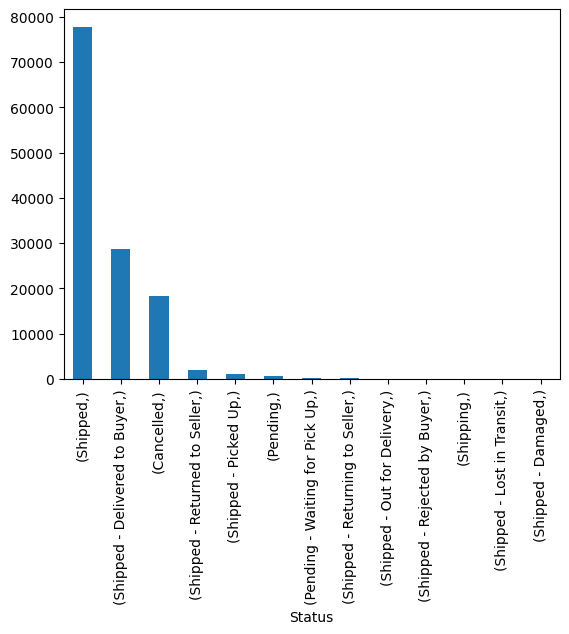

In [25]:
data.value_counts(['Status']).plot(kind='bar')
#use a bar chart here because “Status” is a categorical variable, and we want to compare the count of orders across different statuses visually.

In [27]:
status_count = data.value_counts(['Status'])

status_count = status_count.reset_index()
#turn the index of a Series into a regular column.

In [29]:
type(status_count)

pandas.core.frame.DataFrame

In [30]:
status_count['percentage'] = np.round(100*status_count['count']/sum(status_count['count']),2)
#tells you what % of total orders belong to each order status

In [31]:
status_count

,Status,count,percentage
0,Shipped,77815,60.33
1,Shipped - Delivered to Buyer,28756,22.30
2,Cancelled,18334,14.22
3,Shipped - Returned to Seller,1954,1.52
4,Shipped - Picked Up,973,0.75
5,Pending,658,0.51
6,Pending - Waiting for Pick Up,281,0.22
7,Shipped - Returning to Seller,145,0.11
8,Shipped - Out for Delivery,35,0.03
9,Shipped - Rejected by Buyer,11,0.01


<Axes: xlabel='Status'>

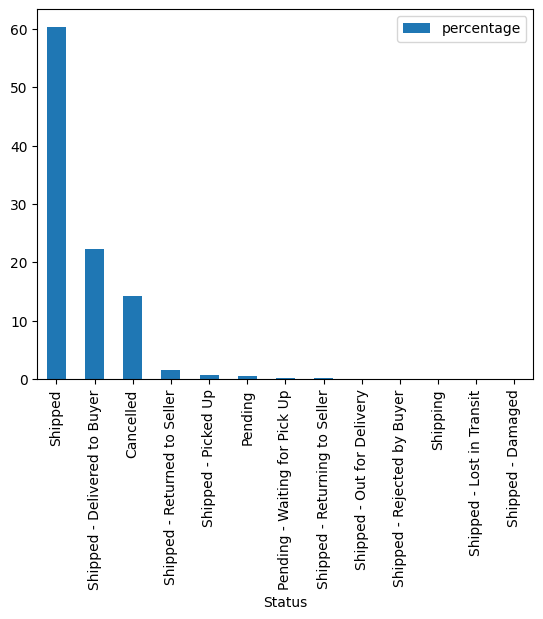

In [33]:
status_count[['Status','percentage']].set_index('Status').plot(kind='bar')

## Fulfilment and fulfilled-by

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128976 non-null  object        
 1   Date                128976 non-null  datetime64[ns]
 2   Status              128976 non-null  object        
 3   Fulfilment          128976 non-null  object        
 4   Sales Channel       128976 non-null  object        
 5   ship-service-level  128976 non-null  object        
 6   Category            128976 non-null  object        
 7   Size                128976 non-null  object        
 8   Courier Status      128976 non-null  object        
 9   Qty                 128976 non-null  int64         
 10  currency            121176 non-null  object        
 11  Amount              121176 non-null  float64       
 12  ship-city           128941 non-null  object        
 13  ship-state          128941 no

In [35]:
data['Fulfilment'].unique()

array(['Merchant', 'Amazon'], dtype=object)

In [36]:
data['Fulfilment'].value_counts()

Fulfilment
Amazon      89713
Merchant    39263
Name: count, dtype: int64

In [37]:
fulfilment_df = data['Fulfilment'].value_counts().reset_index()

In [38]:
fulfilment_df['percentage'] = np.round(100*fulfilment_df['count']/sum(fulfilment_df['count']),2)

In [39]:
fulfilment_df

,Fulfilment,count,percentage
0,Amazon,89713,69.56
1,Merchant,39263,30.44


In [40]:
data[['Fulfilment','fulfilled-by']]

,Fulfilment,fulfilled-by
0,Merchant,Easy Ship
1,Merchant,Easy Ship
2,Amazon,NaN
3,Merchant,Easy Ship
4,Amazon,NaN
...,...,...
128971,Amazon,NaN
128972,Amazon,NaN
128973,Amazon,NaN
128974,Amazon,NaN


In [41]:
data['fulfilled-by'].isnull().sum()

np.int64(89713)

In [42]:
data['fulfilled-by'].value_counts()

fulfilled-by
Easy Ship    39263
Name: count, dtype: int64

## Sales Channel

In [43]:
data['Sales Channel'].value_counts()

Sales Channel
Amazon.in     128852
Non-Amazon       124
Name: count, dtype: int64

In [44]:
data[data['Sales Channel']=='Non-Amazon']

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
938,S02-5278980-4327051,2022-04-30,Shipped,Amazon,Non-Amazon,Standard,Wallet,Free,Unshipped,15,NaN,NaN,Surat,Gujarat,394210.0,IN,False,NaN
1058,S02-9107114-0460608,2022-04-30,Shipped,Amazon,Non-Amazon,Standard,T-shirt,XL,Unshipped,2,NaN,NaN,Surat,Gujarat,394210.0,IN,False,NaN
3632,S02-1006261-5356758,2022-04-28,Shipped,Amazon,Non-Amazon,Standard,Shirt,L,Unshipped,9,NaN,NaN,Surat,Gujarat,394210.0,IN,False,NaN
3633,S02-3681731-6111841,2022-04-28,Shipped,Amazon,Non-Amazon,Standard,Shirt,L,Unshipped,1,NaN,NaN,Surat,Gujarat,394210.0,IN,False,NaN
3635,S02-1926028-4838217,2022-04-28,Shipped,Amazon,Non-Amazon,Standard,Shirt,XS,Unshipped,1,NaN,NaN,Surat,Gujarat,394210.0,IN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118100,S02-9176732-4357939,2022-06-08,Shipped,Amazon,Non-Amazon,Standard,T-shirt,M,Unshipped,1,NaN,NaN,Surat,Gujarat,394210.0,IN,False,NaN
124617,S02-2059602-9568060,2022-06-04,Shipped,Amazon,Non-Amazon,Standard,Shirt,S,Unshipped,1,NaN,NaN,Surat,Gujarat,394210.0,IN,False,NaN
124618,S02-3811761-8377519,2022-06-04,Shipped,Amazon,Non-Amazon,Standard,T-shirt,XS,Unshipped,2,NaN,NaN,Surat,Gujarat,394210.0,IN,False,NaN
124620,S02-5216693-3162561,2022-06-04,Shipped,Amazon,Non-Amazon,Standard,T-shirt,XXL,Unshipped,1,NaN,NaN,Surat,Gujarat,394210.0,IN,False,NaN


## Ship Service Level

In [45]:
data['ship-service-level'].value_counts()

ship-service-level
Expedited    88630
Standard     40346
Name: count, dtype: int64

## Category

In [46]:
data['Category'].value_counts()

Category
T-shirt     50292
Shirt       49877
Blazzer     15500
Trousers    10616
Perfume      1157
Wallet        926
Socks         440
Shoes         165
Watch           3
Name: count, dtype: int64

In [47]:
data

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128971,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,False,NaN
128972,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,False,NaN
128973,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,Blazzer,XXL,Shipped,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,False,NaN
128974,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,1,INR,1199.00,Halol,Gujarat,389350.0,IN,False,NaN


In [50]:
category_df = data[['Category', 'Qty', 'Amount']].groupby('Category').aggregate('sum')

In [52]:
data['Category'].value_counts()

Category
T-shirt     50292
Shirt       49877
Blazzer     15500
Trousers    10616
Perfume      1157
Wallet        926
Socks         440
Shoes         165
Watch           3
Name: count, dtype: int64

In [53]:
category_df.sort_values('Qty',ascending=False)

,Qty,Amount
Category,,
T-shirt,45292,39206756.65
Shirt,45044,21297770.08
Blazzer,13943,11215104.12
Trousers,9898,5346286.30
Perfume,1051,789419.66
Wallet,863,458408.18
Socks,399,150757.50
Shoes,153,124752.76
Watch,3,915.00


In [ ]:
category_df['avg price'] = np.round(category_df['Amount']/category_df['Qty'],2)

In [55]:
category_df = category_df.sort_values('Qty', ascending=False)
category_df

,Qty,Amount,avg price
Category,,,
T-shirt,45292,39206756.65,865.64
Shirt,45044,21297770.08,472.82
Blazzer,13943,11215104.12,804.35
Trousers,9898,5346286.30,540.14
Perfume,1051,789419.66,751.11
Wallet,863,458408.18,531.18
Socks,399,150757.50,377.84
Shoes,153,124752.76,815.38
Watch,3,915.00,305.00


## Category and Size

In [56]:
# How many different types of sizes are there in the t-shirt category in the dataset

t_shirt_df = data[data['Category'] == 'T-shirt']
t_shirt_df

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship
5,404-1490984-4578765,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XL,Shipped,1,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102.0,IN,False,NaN
6,408-5748499-6859555,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,L,Shipped,1,INR,653.00,CHANDIGARH,CHANDIGARH,160036.0,IN,False,NaN
8,407-5443024-5233168,2022-04-30,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,3XL,Cancelled,0,NaN,NaN,HYDERABAD,TELANGANA,500008.0,IN,False,NaN
13,408-7955685-3083534,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,1,INR,657.00,MUMBAI,MAHARASHTRA,400053.0,IN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128969,403-7059995-7618722,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XL,Shipped,1,INR,824.00,Delhi,DELHI,110053.0,IN,False,NaN
128970,404-3802633-7250760,2022-05-31,Cancelled,Amazon,Amazon.in,Expedited,T-shirt,M,Unshipped,1,INR,612.00,MUMBAI,MAHARASHTRA,400017.0,IN,False,NaN
128972,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,False,NaN
128974,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,1,INR,1199.00,Halol,Gujarat,389350.0,IN,False,NaN


In [58]:
t_shirt_df.value_counts('Size')

Size
M      9351
L      8192
XL     7573
S      7509
XXL    6166
3XL    5796
XS     5515
6XL      81
5XL      61
4XL      48
Name: count, dtype: int64

In [61]:
cat_size_df = data[['Category','Size']].value_counts().reset_index()

In [62]:
cat_size_df = cat_size_df.sort_values(['Category','Size'])

In [63]:
cat_size_df

,Category,Size,count
19,Blazzer,3XL,1913
14,Blazzer,L,2844
15,Blazzer,M,2588
17,Blazzer,S,2226
16,Blazzer,XL,2380
24,Blazzer,XS,1430
18,Blazzer,XXL,2119
27,Perfume,Free,1157
11,Shirt,3XL,5687
32,Shirt,4XL,379


In [65]:
cat_size_df[cat_size_df['count']==cat_size_df['count'].max()]

,Category,Size,count
0,T-shirt,M,9351


In [66]:
data[['Category','Size', 'Qty', 'Amount']].groupby(['Category', 'Size']).aggregate('sum').sort_values('Amount', ascending=False)

Qty      Amount
Category Size                  
T-shirt  M     8362  7305376.89
         L     7396  6354895.10
         XL    6874  5937447.97
         S     6704  5832475.07
         XXL   5604  4763380.90
         3XL   5287  4529937.41
         XS    4890  4267824.00
Shirt    L     8049  3732265.17
         XL    7837  3631637.95
         M     7706  3544564.45
         XXL   6946  3221536.90
         3XL   5134  2454796.34
         S     5161  2352487.64
Blazzer  L     2545  2026215.69
         M     2327  1880455.49
         XL    2126  1727110.99
         S     1963  1602762.85
         XXL   1945  1572849.94
         3XL   1758  1406828.11
Shirt    XS    2787  1240043.34
Blazzer  XS    1279   998881.05
Trousers M     1693   942664.71
         XL    1735   933873.84
         L     1648   901056.86
         XXL   1687   883726.99
Perfume  Free  1051   789419.66
Trousers 3XL   1121   618261.81
         S     1146   617436.62
Shirt    6XL    616   485831.26
Wallet   Free   863   458408.18
Trousers XS     868   449265.47
Shirt    5XL    456   357467.63
         4XL    352   277139.40
Shoes    Free   153   124752.76
T-shirt  6XL     72    90418.07
         5XL     57    67689.00
         4XL     46    57312.24
Socks    XL      64    25879.63
         L       68    25391.21
         3XL     60    24332.63
         XXL     64    23482.96
         S       67    22598.76
         M       50    19580.59
         XS      26     9491.72
Watch    Free     3      915.00

## Courier Status

In [16]:
data['Courier Status']

0         On the Way
1            Shipped
2            Shipped
3         On the Way
4            Shipped
             ...    
128971       Shipped
128972       Shipped
128973       Shipped
128974       Shipped
128975       Shipped
Name: Courier Status, Length: 128976, dtype: object

In [17]:
data['Courier Status'].value_counts()

Courier Status
Shipped       109486
On the Way      6870
Unshipped       6680
Cancelled       5940
Name: count, dtype: int64

In [18]:
Courier_status_df = data['Courier Status'].value_counts().reset_index()

In [19]:
Courier_status_df['percentage'] = np.round(100*Courier_status_df['count']/sum(Courier_status_df['count']),2)

Courier_status_df

,Courier Status,count,percentage
0,Shipped,109486,84.89
1,On the Way,6870,5.33
2,Unshipped,6680,5.18
3,Cancelled,5940,4.61


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

<Axes: xlabel='Date'>

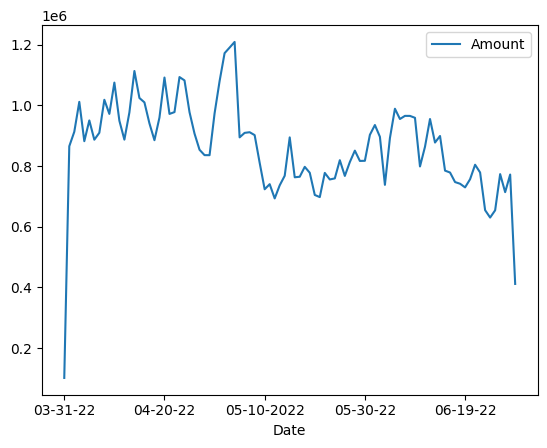

In [21]:
data[['Date','Amount']].groupby('Date').aggregate('sum').plot()

In [22]:
df = data[['Date','Amount']].groupby('Date').aggregate('sum')

df[df['Amount']==df['Amount'].max()]

,Amount
Date,
05-04-2022,1209364.17


In [23]:
df[df['Amount']==df['Amount'].min()]

,Amount
Date,
03-31-22,101683.85


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

## Ship-City

In [25]:
data['ship-city'].value_counts()

ship-city
BENGALURU       11208
HYDERABAD        8077
MUMBAI           6125
NEW DELHI        5792
CHENNAI          5430
                ...  
Thank               1
Vaduvanchal         1
Yamuna Vihar        1
MEENANGADI          1
Bisalpur            1
Name: count, Length: 8948, dtype: int64

In [26]:
top_10_ship_city = data['ship-city'].value_counts()[:10]

top_10_ship_city

ship-city
BENGALURU    11208
HYDERABAD     8077
MUMBAI        6125
NEW DELHI     5792
CHENNAI       5430
PUNE          3863
KOLKATA       2380
GURUGRAM      1865
THANE         1701
LUCKNOW       1462
Name: count, dtype: int64

<Axes: xlabel='ship-city'>

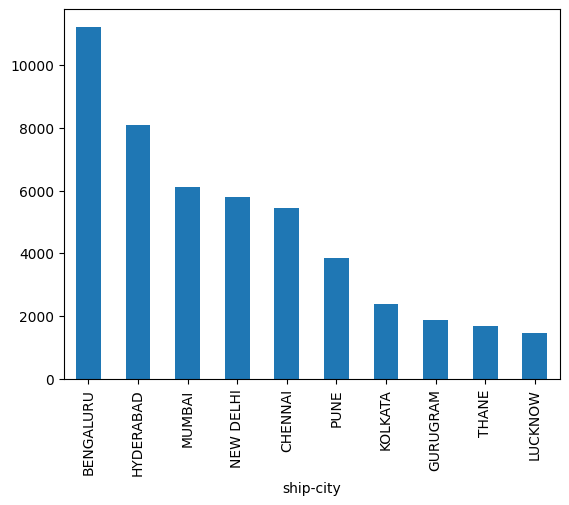

In [27]:
top_10_ship_city.plot(kind='bar')

## Ship- State

First convert all the state names to lower case

In [28]:
data['ship-state'] = data['ship-state'].apply(lambda x: str(x).lower())

In [29]:
data['ship-state'].value_counts()

ship-state
maharashtra               22272
karnataka                 17324
tamil nadu                11488
telangana                 11330
uttar pradesh             10646
delhi                      6963
kerala                     6577
west bengal                5962
andhra pradesh             5427
gujarat                    4482
haryana                    4410
rajasthan                  2713
madhya pradesh             2532
odisha                     2136
bihar                      2113
punjab                     1919
assam                      1664
uttarakhand                1552
jharkhand                  1457
goa                        1137
chhattisgarh                909
himachal pradesh            789
jammu & kashmir             702
puducherry                  348
chandigarh                  334
manipur                     314
andaman & nicobar           256
meghalaya                   207
sikkim                      205
nagaland                    185
tripura                     1

In [30]:
top_10_ship_state = data['ship-state'].value_counts()[:10]

top_10_ship_state

ship-state
maharashtra       22272
karnataka         17324
tamil nadu        11488
telangana         11330
uttar pradesh     10646
delhi              6963
kerala             6577
west bengal        5962
andhra pradesh     5427
gujarat            4482
Name: count, dtype: int64

<Axes: xlabel='ship-state'>

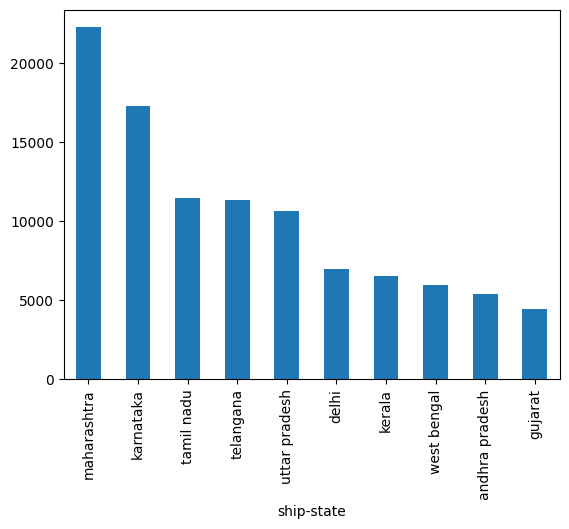

In [31]:
top_10_ship_state.plot(kind='bar')